In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import norm
from datetime import datetime

from Database.queries import *
from Features.features import *

In [2]:
get_universe(asset_types=None)

,ticker,company_name,exchange,currency,asset_type,country,sector,industry,timezone,last_updated
0,AAPL,Apple Inc.,NMS,USD,equity,United States,Technology,Consumer Electronics,America/New_York,2026-07-17 23:09:50.192082
1,GOOGL,Alphabet Inc.,NMS,USD,equity,United States,Communication Services,Internet Content & Information,America/New_York,2026-07-18 14:03:57.645764
2,TSLA,"Tesla, Inc.",NMS,USD,equity,United States,Consumer Cyclical,Auto Manufacturers,America/New_York,2026-07-17 23:09:49.559242


In [3]:
get_assets(['AAPL', 'TSLA'])

,ticker,company_name,exchange,currency,asset_type,country,sector,industry,timezone,last_updated
0,AAPL,Apple Inc.,NMS,USD,equity,United States,Technology,Consumer Electronics,America/New_York,2026-07-17 23:09:50.192082
1,TSLA,"Tesla, Inc.",NMS,USD,equity,United States,Consumer Cyclical,Auto Manufacturers,America/New_York,2026-07-17 23:09:49.559242


In [4]:
start = datetime(2020, 7, 16)
end = datetime(2025, 7, 15)

get_daily_prices(assets=None, start=start, end=None)

,ticker,date,open,high,low,close,adj_close,volume,last_updated
0,AAPL,2020-07-16,96.562500,97.404999,95.904999,96.522499,93.455772,110577600,2026-07-17 23:18:52.644484
1,GOOGL,2020-07-16,75.074997,75.795502,74.413498,75.746002,75.080254,26484000,2026-07-18 14:04:00.046518
2,TSLA,2020-07-16,98.477333,102.113998,97.733330,100.042664,100.042664,214512000,2026-07-17 23:18:51.189613
3,AAPL,2020-07-17,96.987503,97.147499,95.839996,96.327499,93.266983,92186800,2026-07-17 23:18:52.644484
4,GOOGL,2020-07-17,75.845497,76.171501,74.904999,75.842499,75.175888,34264000,2026-07-18 14:04:00.046518
...,...,...,...,...,...,...,...,...,...
4519,GOOGL,2026-07-16,373.059998,375.269989,352.299988,354.459991,354.459991,41158500,2026-07-18 14:04:00.046518
4520,TSLA,2026-07-16,392.350006,395.309998,385.320007,391.059998,391.059998,29269100,2026-07-17 23:18:51.189613
4521,AAPL,2026-07-17,331.980011,334.980011,329.000610,333.739990,333.739990,63325386,2026-07-17 23:18:52.644484
4522,GOOGL,2026-07-17,346.000000,348.519989,341.359985,346.769989,346.769989,29929300,2026-07-18 14:04:00.046518


In [5]:
start = datetime(2020, 7, 16)
end = datetime(2025, 6, 9)

get_dividends(assets=['GOOGL', 'AAPL'], start=start, end=None)

,ticker,ex_date,dividend,last_updated
0,AAPL,2020-08-07,0.205,2026-07-18 11:29:23.779205
1,AAPL,2020-11-06,0.205,2026-07-18 11:29:23.779205
2,AAPL,2021-02-05,0.205,2026-07-18 11:29:23.779205
3,AAPL,2021-05-07,0.220,2026-07-18 11:29:23.779205
4,AAPL,2021-08-06,0.220,2026-07-18 11:29:23.779205
5,AAPL,2021-11-05,0.220,2026-07-18 11:29:23.779205
6,AAPL,2022-02-04,0.220,2026-07-18 11:29:23.779205
7,AAPL,2022-05-06,0.230,2026-07-18 11:29:23.779205
8,AAPL,2022-08-05,0.230,2026-07-18 11:29:23.779205
9,AAPL,2022-11-04,0.230,2026-07-18 11:29:23.779205


In [6]:
get_latest_price(assets=None)

,ticker,date,open,high,low,close,adj_close,volume,last_updated
0,AAPL,2026-07-17,331.980011,334.980011,329.000610,333.739990,333.739990,63325386,2026-07-17 23:18:52.644484
1,GOOGL,2026-07-17,346.000000,348.519989,341.359985,346.769989,346.769989,29929300,2026-07-18 14:04:00.046518
2,TSLA,2026-07-17,381.779999,385.689911,377.220001,380.839996,380.839996,29958144,2026-07-17 23:18:51.189613


In [7]:
get_latest_dividend(assets=None)

,ticker,ex_date,dividend,last_updated
0,AAPL,2026-05-11,0.27,2026-07-18 11:29:23.779205
1,GOOGL,2026-06-08,0.22,2026-07-18 14:04:04.215929


In [8]:
get_prices(field='close', pivot=False)

,date,ticker,close
0,1980-12-12,AAPL,0.128348
1,1980-12-15,AAPL,0.121652
2,1980-12-16,AAPL,0.112723
3,1980-12-17,AAPL,0.115513
4,1980-12-18,AAPL,0.118862
...,...,...,...
21034,2026-07-16,GOOGL,354.459991
21035,2026-07-16,TSLA,391.059998
21036,2026-07-17,AAPL,333.739990
21037,2026-07-17,GOOGL,346.769989


In [9]:
prices = get_prices(field='close', pivot=True)
returns = get_returns(prices)
returns

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,NaN,NaN,NaN
1980-12-15,-0.052171,NaN,NaN
1980-12-16,-0.073398,NaN,NaN
1980-12-17,0.024751,NaN,NaN
1980-12-18,0.028992,NaN,NaN
...,...,...,...
2026-07-13,0.006311,-0.013075,-0.031881
2026-07-14,-0.007721,0.019858,0.003597
2026-07-15,0.040145,0.031738,-0.004341


In [10]:
def get_distribution(data):
    r = data.dropna()
    mu = r.mean()
    sigma = r.std()
    
    # Histograma normalizado
    plt.hist(r, bins=150, density=True, edgecolor="black", alpha=0.6, label='Empirical')
    
    # Curva normal ajustada
    x = np.linspace(r.min(), r.max(), 1000)
    y = norm.pdf(x, loc=mu, scale=sigma)
    plt.plot(x, y, linewidth=2, color='black', label="Normal")
    
    #plt.xlim(-0.2, 0.2)
    plt.title("Distribution")
    plt.legend()
    plt.show()
    
    print(f"Mean: {mu:.5f}")
    print(f"Std: {sigma:.5f}")
    print(f"Skewness: {r.skew():.3f}")
    print(f"Kurtosis: {r.kurt():.3f}")

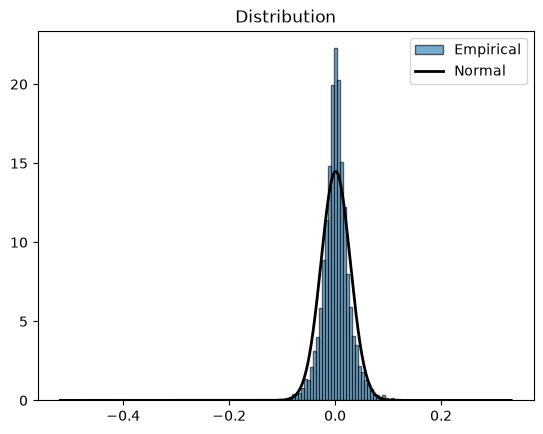

Mean: 0.00107
Std: 0.02754
Skewness: -0.362
Kurtosis: 18.703


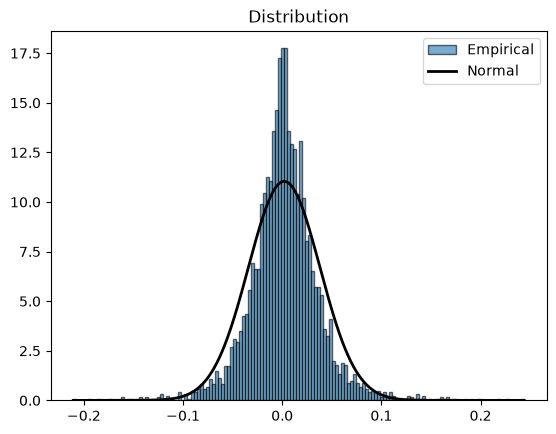

Mean: 0.00201
Std: 0.03614
Skewness: 0.374
Kurtosis: 4.898


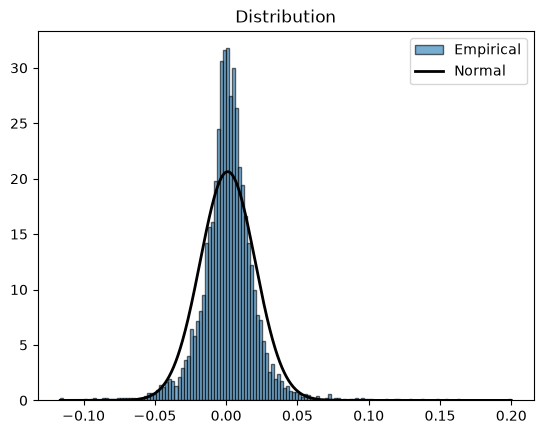

Mean: 0.00108
Std: 0.01933
Skewness: 0.611
Kurtosis: 8.705


In [11]:
get_distribution(returns['AAPL'])
get_distribution(returns['TSLA'])
get_distribution(returns['GOOGL'])

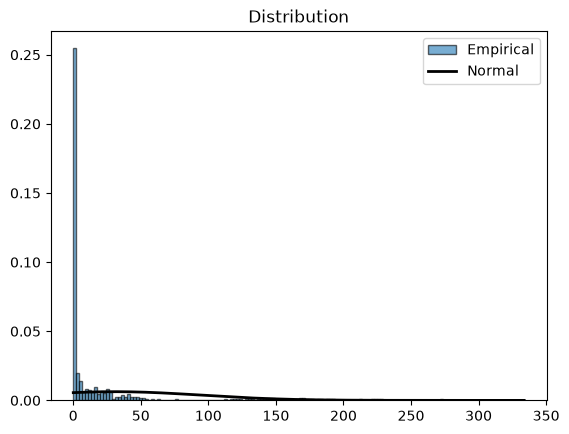

Mean: 30.83862
Std: 63.38316
Skewness: 2.385
Kurtosis: 4.775


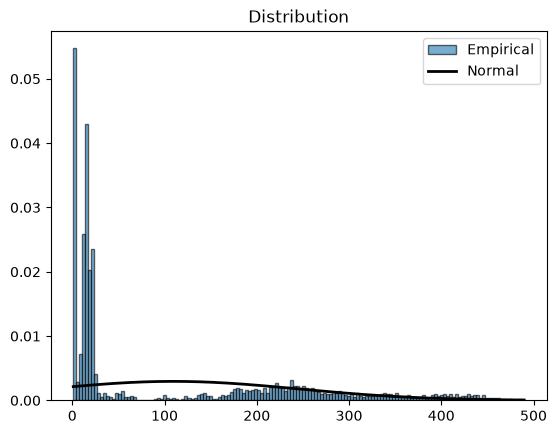

Mean: 109.37943
Std: 134.94753
Skewness: 1.011
Kurtosis: -0.350


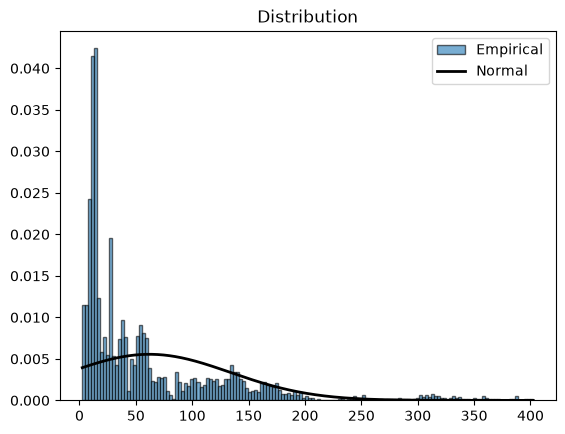

Mean: 62.01911
Std: 71.85445
Skewness: 2.080
Kurtosis: 4.791


In [12]:
prices = get_prices(['AAPL', 'TSLA', 'GOOGL'], field='adj_close', pivot=True)
get_distribution(prices['AAPL'])
get_distribution(prices['TSLA'])
get_distribution(prices['GOOGL'])

In [13]:
mom = momentum(prices)
mom

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,NaN,NaN,NaN
1980-12-15,NaN,NaN,NaN
1980-12-16,NaN,NaN,NaN
1980-12-17,NaN,NaN,NaN
1980-12-18,NaN,NaN,NaN
...,...,...,...
2026-07-13,0.499783,0.990292,0.273954
2026-07-14,0.497012,1.000863,0.263692
2026-07-15,0.576068,1.048789,0.244746


In [14]:
get_log_returns(prices)

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,NaN,NaN,NaN
1980-12-15,-0.053581,NaN,NaN
1980-12-16,-0.076231,NaN,NaN
1980-12-17,0.024450,NaN,NaN
1980-12-18,0.028580,NaN,NaN
...,...,...,...
2026-07-13,0.006291,-0.013161,-0.032401
2026-07-14,-0.007751,0.019663,0.003591
2026-07-15,0.039360,0.031244,-0.004351


In [15]:
realized_vol(prices)

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,NaN,NaN,NaN
1980-12-15,NaN,NaN,NaN
1980-12-16,NaN,NaN,NaN
1980-12-17,NaN,NaN,NaN
1980-12-18,NaN,NaN,NaN
...,...,...,...
2026-07-13,0.349695,0.324556,0.599226
2026-07-14,0.345275,0.332050,0.595598
2026-07-15,0.365336,0.337625,0.593945


In [16]:
sma(prices)

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,NaN,NaN,NaN
1980-12-15,NaN,NaN,NaN
1980-12-16,NaN,NaN,NaN
1980-12-17,NaN,NaN,NaN
1980-12-18,NaN,NaN,NaN
...,...,...,...
2026-07-13,298.674736,372.677266,409.635599
2026-07-14,299.549930,372.176061,409.926599
2026-07-15,300.502288,371.885266,409.999399


In [17]:
ema(prices)

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,0.098207,NaN,NaN
1980-12-15,0.098006,NaN,NaN
1980-12-16,0.097545,NaN,NaN
1980-12-17,0.097186,NaN,NaN
1980-12-18,0.096941,NaN,NaN
...,...,...,...
2026-07-13,295.619369,359.014915,403.439861
2026-07-14,296.373903,359.034330,403.155160
2026-07-15,297.594534,359.500435,402.814173


In [18]:
cross_sectional_rank(mom)

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,NaN,NaN,NaN
1980-12-15,NaN,NaN,NaN
1980-12-16,NaN,NaN,NaN
1980-12-17,NaN,NaN,NaN
1980-12-18,NaN,NaN,NaN
...,...,...,...
2026-07-13,2.0,1.0,3.0
2026-07-14,2.0,1.0,3.0
2026-07-15,2.0,1.0,3.0


In [19]:
zscore(mom)

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,NaN,NaN,NaN
1980-12-15,NaN,NaN,NaN
1980-12-16,NaN,NaN,NaN
1980-12-17,NaN,NaN,NaN
1980-12-18,NaN,NaN,NaN
...,...,...,...
2026-07-13,-0.240906,1.098448,-0.857541
2026-07-14,-0.239343,1.097954,-0.858611
2026-07-15,-0.116641,1.053205,-0.936565


In [26]:
rank = cross_sectional_rank(mom)
isna = rank.isna().sum(axis=1).value_counts().sort_index()
isna

0    3785
1    1475
2    5978
3     252
Name: count, dtype: int64

In [32]:
selected = rank <= 2
weights = selected.div(selected.sum(axis=1), axis="index").fillna(0)
weights

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,0.0,0.0,0.0
1980-12-15,0.0,0.0,0.0
1980-12-16,0.0,0.0,0.0
1980-12-17,0.0,0.0,0.0
1980-12-18,0.0,0.0,0.0
...,...,...,...
2026-07-13,0.5,0.5,0.0
2026-07-14,0.5,0.5,0.0
2026-07-15,0.5,0.5,0.0


In [42]:
short_ma = sma(prices, window=25)
long_ma = sma(prices, 45)

In [45]:
(short_ma > long_ma).head(50)

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,False,False,False
1980-12-15,False,False,False
1980-12-16,False,False,False
1980-12-17,False,False,False
1980-12-18,False,False,False
1980-12-19,False,False,False
1980-12-22,False,False,False
1980-12-23,False,False,False
1980-12-24,False,False,False


In [49]:
short_ma > long_ma
weights = (short_ma > long_ma)

ticker,AAPL,GOOGL,TSLA
date,,,
1980-12-12,False,False,False
1980-12-15,False,False,False
1980-12-16,False,False,False
1980-12-17,False,False,False
1980-12-18,False,False,False
...,...,...,...
2026-07-13,False,False,False
2026-07-14,False,False,False
2026-07-15,False,False,False
